# Your first CV cluster state

Build a three-mode resource and inspect its nullifier noise.

For a graph adjacency A, ideal nullifiers are p-Aq. Finite momentum squeezing gives residual variance exp(-2r). A resource without measurements has no classical outcomes.

Output modes: (0, 1, 2)
Nullifier covariance: [[0.246597 0.       0.      ]
 [0.       0.246597 0.      ]
 [0.       0.       0.246597]]


<Axes: title={'center': 'MBQC connectivity Â· squares: inputs Â· diamonds: outputs\ntriangles: PNR Â· dashed arrows: classical control'}>

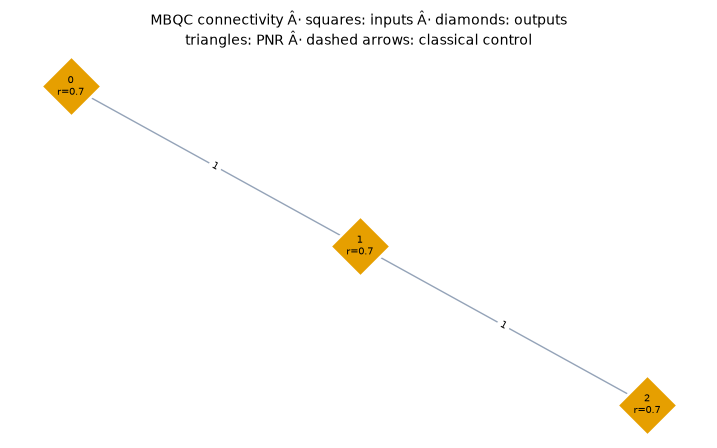

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import photographiq as pg
graph = pg.CVGraph.line(3, squeezing=0.7)
pattern = pg.Pattern(graph)
result = pg.simulate(pattern, backend="gaussian", seed=7)
nullifiers = graph.nullifiers()
noise = nullifiers @ result.state.covariance @ nullifiers.T
print("Output modes:", result.state.nodes)
print("Nullifier covariance:", np.round(noise, 6))
np.testing.assert_allclose(noise, np.eye(3)*np.exp(-1.4), atol=1e-12)
pattern.draw()

## Interpretation

The diagonal entries are residual nullifier variances. Their nonzero values reflect finite squeezing, not a failed entangling operation.

## Exercise

Change squeezing to 0.4 and 1.0. Predict the variance ratio before running. Then replace the line with a ring.